<a href="https://colab.research.google.com/github/hansiniarangi1211/Real-Time-Object-Detection-using-YOLO-vs-Faster-R-CNN/blob/main/24AI10018_Hansini_03032026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Real-Time Object Detection Using Custom Dataset (YOLO vs Faster R-CNN From Scratch)

## Problem Statement

Design a real-time object detection system that detects:

- number plate

https://universe.roboflow.com/ekant-swami/helmate

https://www.kaggle.com/datasets/pkdarabi/helmet/data

## Data Preparation

### Load the Dataset

In [ ]:
# Install dependencies
!pip install -q kagglehub albumentations

import os, glob, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import Counter

import kagglehub

# Download the HelmetViolations dataset
path = kagglehub.dataset_download("pkdarabi/helmet")
print("Dataset downloaded to:", path)

# Find images and labels
img_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
all_images = []
for root, dirs, files in os.walk(path):
    for f in files:
        if f.lower().endswith(img_extensions):
            all_images.append(os.path.join(root, f))

print(f"Found {len(all_images)} images total")

# Build (image, label) pairs
pairs = []
for img_path in all_images:
    base = os.path.splitext(img_path)[0]
    lbl_path = base + '.txt'
    # Also check labels/ folder variant
    if not os.path.exists(lbl_path):
        lbl_path = img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
    if os.path.exists(lbl_path):
        pairs.append((img_path, lbl_path))

print(f"Found {len(pairs)} image-label pairs")

CLASS_NAMES = ['Plate', 'WithHelmet', 'WithoutHelmet']
NUM_CLASSES = len(CLASS_NAMES)

Using Colab cache for faster access to the 'helmet' dataset.
Dataset downloaded to: /kaggle/input/helmet
Found 1937 images total
Found 1937 image-label pairs


### Perform train/val/test split (70/20/10)


In [ ]:
from sklearn.model_selection import train_test_split

random.seed(42)
random.shuffle(pairs)

train_val, test_pairs = train_test_split(pairs, test_size=0.10, random_state=42)
train_pairs, val_pairs = train_test_split(train_val, test_size=0.2222, random_state=42)  # 0.2222 of 0.9 ≈ 0.2

print(f"Train: {len(train_pairs)}, Val: {len(val_pairs)}, Test: {len(test_pairs)}")

def parse_yolo_label(label_path, img_w, img_h):
    """Parse YOLO format: class_id x_center y_center width height (normalized)"""
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            xc, yc, w, h = [float(v) for v in parts[1:5]]
            x1 = (xc - w/2) * img_w
            y1 = (yc - h/2) * img_h
            x2 = (xc + w/2) * img_w
            y2 = (yc + h/2) * img_h
            boxes.append([cls_id, x1, y1, x2, y2])
    return boxes

Train: 1355, Val: 388, Test: 194


### Apply augmentation:

- Horizontal flip

- Brightness change

- Scaling

- Random crop


In [ ]:
import albumentations as A

augmentation_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.RandomScale(scale_limit=0.2, p=0.5),
    A.RandomCrop(width=416, height=416, p=0.3),
    A.Resize(448, 448),
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'], min_visibility=0.3))

def augment_sample(img_path, label_path):
    img = np.array(Image.open(img_path).convert('RGB'))
    h, w = img.shape[:2]
    boxes_raw = parse_yolo_label(label_path, w, h)
    if not boxes_raw:
        img_resized = A.Resize(448,448)(image=img)['image']
        return img_resized, [], []
    class_labels = [b[0] for b in boxes_raw]
    bboxes = [[b[1],b[2],b[3],b[4]] for b in boxes_raw]
    # Clip bboxes
    bboxes = [[max(0,b[0]),max(0,b[1]),min(w,b[2]),min(h,b[3])] for b in bboxes]
    bboxes = [[b[0],b[1],max(b[0]+1,b[2]),max(b[1]+1,b[3])] for b in bboxes]
    try:
        result = augmentation_pipeline(image=img, bboxes=bboxes, class_labels=class_labels)
        return result['image'], result['bboxes'], result['class_labels']
    except:
        img_resized = A.Resize(448,448)(image=img)['image']
        return img_resized, [], []

# Test augmentation
img, bboxes, labels = augment_sample(*train_pairs[0])
print(f"Augmented image shape: {img.shape}, boxes: {len(bboxes)}")

Augmented image shape: (448, 448, 3), boxes: 1


### Plot:

- Class distribution

- Bounding box size distribution


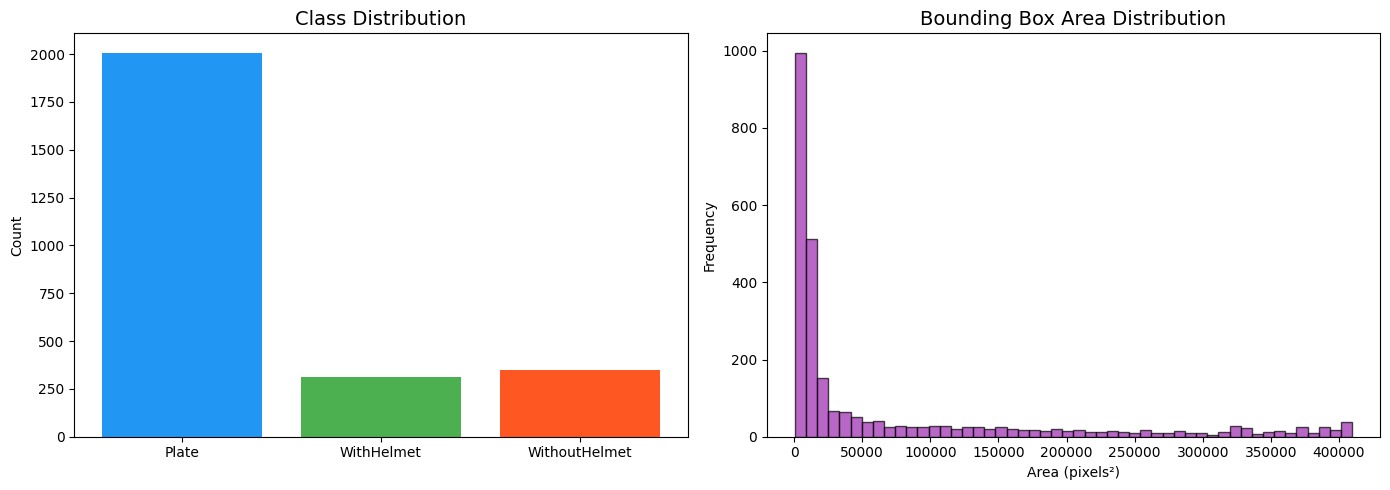

In [ ]:
all_classes = []
all_box_areas = []

for img_path, lbl_path in pairs:
    img = Image.open(img_path)
    w, h = img.size
    boxes = parse_yolo_label(lbl_path, w, h)
    for b in boxes:
        all_classes.append(b[0])
        bw = b[3] - b[1]
        bh = b[4] - b[2]
        all_box_areas.append(bw * bh)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
class_counts = Counter(all_classes)
names = [CLASS_NAMES[i] if i < len(CLASS_NAMES) else f"cls_{i}" for i in sorted(class_counts.keys())]
counts = [class_counts[i] for i in sorted(class_counts.keys())]
axes[0].bar(names, counts, color=['#2196F3','#4CAF50','#FF5722'])
axes[0].set_title('Class Distribution', fontsize=14)
axes[0].set_ylabel('Count')

# BBox size distribution
axes[1].hist(all_box_areas, bins=50, color='#9C27B0', alpha=0.7, edgecolor='black')
axes[1].set_title('Bounding Box Area Distribution', fontsize=14)
axes[1].set_xlabel('Area (pixels²)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Deliver:

- Atleast 3 annotated samples

- Histogram plots

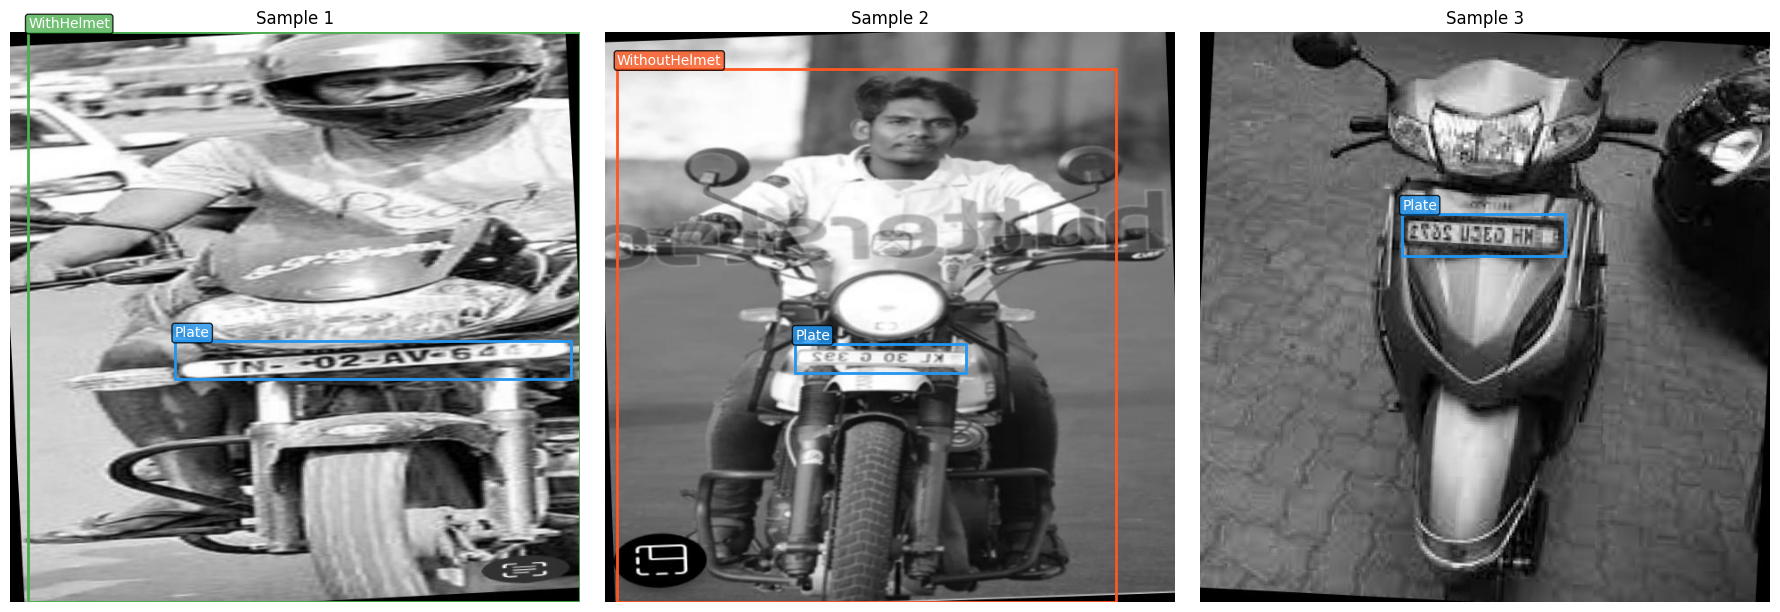

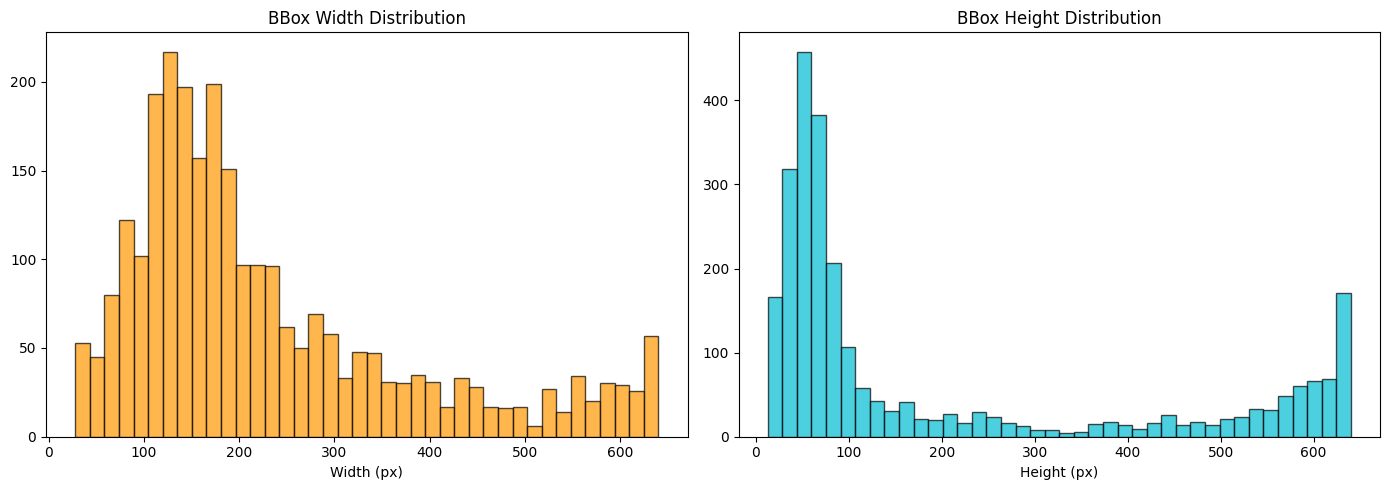

In [ ]:
COLORS = {0:'#2196F3', 1:'#4CAF50', 2:'#FF5722'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, ax in enumerate(axes):
    img_path, lbl_path = pairs[idx]
    img = np.array(Image.open(img_path).convert('RGB'))
    h, w = img.shape[:2]
    boxes = parse_yolo_label(lbl_path, w, h)
    ax.imshow(img)
    for b in boxes:
        cls, x1, y1, x2, y2 = b
        rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor=COLORS.get(cls,'yellow'), facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-5, CLASS_NAMES[cls] if cls<len(CLASS_NAMES) else str(cls),
                color='white', fontsize=10, bbox=dict(boxstyle='round,pad=0.2',
                facecolor=COLORS.get(cls,'yellow'), alpha=0.8))
    ax.set_title(f'Sample {idx+1}')
    ax.axis('off')
plt.tight_layout()
plt.show()

# Additional histogram: bbox width vs height
all_w, all_h = [], []
for img_path, lbl_path in pairs:
    img = Image.open(img_path)
    iw, ih = img.size
    for b in parse_yolo_label(lbl_path, iw, ih):
        all_w.append(b[3]-b[1])
        all_h.append(b[4]-b[2])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(all_w, bins=40, color='#FF9800', alpha=0.7, edgecolor='black')
axes[0].set_title('BBox Width Distribution')
axes[0].set_xlabel('Width (px)')
axes[1].hist(all_h, bins=40, color='#00BCD4', alpha=0.7, edgecolor='black')
axes[1].set_title('BBox Height Distribution')
axes[1].set_xlabel('Height (px)')
plt.tight_layout()
plt.show()

## YOLO




In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

IMG_SIZE = 448
S = 7          # grid size
B = 2          # boxes per cell
C = NUM_CLASSES  # 3

class YOLODataset(Dataset):
    def __init__(self, pairs, S=7, B=2, C=3, img_size=448):
        self.pairs = pairs
        self.S, self.B, self.C = S, B, C
        self.img_size = img_size
        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, lbl_path = self.pairs[idx]
        img = Image.open(img_path).convert('RGB')
        orig_w, orig_h = img.size
        img_tensor = self.transform(img)

        # Target: S x S x (C + B*5)
        target = torch.zeros(self.S, self.S, self.C + self.B * 5)

        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls_id = int(parts[0])
                xc, yc, w, h = [float(v) for v in parts[1:5]]

                # Grid cell
                gi = int(xc * self.S)
                gj = int(yc * self.S)
                gi = min(gi, self.S - 1)
                gj = min(gj, self.S - 1)

                # Position relative to cell
                x_cell = xc * self.S - gi
                y_cell = yc * self.S - gj

                if target[gj, gi, self.C] == 0:  # not yet assigned
                    target[gj, gi, cls_id] = 1  # class one-hot
                    for b in range(self.B):
                        offset = self.C + b * 5
                        target[gj, gi, offset] = 1     # objectness
                        target[gj, gi, offset+1] = x_cell
                        target[gj, gi, offset+2] = y_cell
                        target[gj, gi, offset+3] = w
                        target[gj, gi, offset+4] = h

        return img_tensor, target

train_ds = YOLODataset(train_pairs, S=S, B=B, C=C)
val_ds = YOLODataset(val_pairs, S=S, B=B, C=C)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=2)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Using device: cuda
Train batches: 170, Val batches: 49


### Implement:

Custom CNN backbone

Grid-based detection head

Bounding box regression

Objectness score

Class prediction

IoU calculation


YOLO model parameters: 265,679,421
YOLO Epoch [5/10] Train Loss: 8.0009 Val Loss: 6.7263
YOLO Epoch [10/10] Train Loss: 11.2313 Val Loss: 13.9343


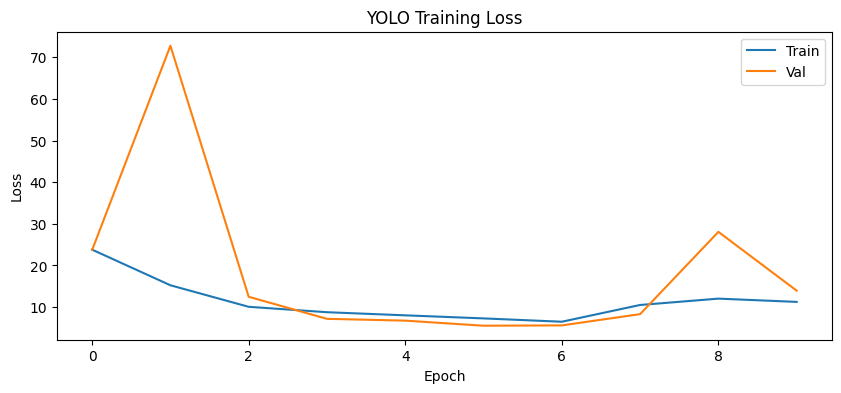

In [ ]:
def compute_iou(box1, box2):
    """Compute IoU between two sets of boxes [x1,y1,x2,y2]."""
    x1 = torch.max(box1[..., 0], box2[..., 0])
    y1 = torch.max(box1[..., 1], box2[..., 1])
    x2 = torch.min(box1[..., 2], box2[..., 2])
    y2 = torch.min(box1[..., 3], box2[..., 3])
    inter = torch.clamp(x2 - x1, min=0) * torch.clamp(y2 - y1, min=0)
    area1 = (box1[...,2]-box1[...,0]) * (box1[...,3]-box1[...,1])
    area2 = (box2[...,2]-box2[...,0]) * (box2[...,3]-box2[...,1])
    union = area1 + area2 - inter + 1e-6
    return inter / union


class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c, k=3, s=1, p=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, k, s, p, bias=False),
            nn.BatchNorm2d(out_c),
            nn.LeakyReLU(0.1, inplace=True)
        )
    def forward(self, x):
        return self.conv(x)


class YOLOBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 64, 7, 2, 3),       # 448->224
            nn.MaxPool2d(2, 2),               # 224->112
            ConvBlock(64, 192, 3, 1, 1),
            nn.MaxPool2d(2, 2),               # 112->56
            ConvBlock(192, 128, 1, 1, 0),
            ConvBlock(128, 256, 3, 1, 1),
            ConvBlock(256, 256, 1, 1, 0),
            ConvBlock(256, 512, 3, 1, 1),
            nn.MaxPool2d(2, 2),               # 56->28
            # Repeated blocks
            ConvBlock(512, 256, 1, 1, 0),
            ConvBlock(256, 512, 3, 1, 1),
            ConvBlock(512, 256, 1, 1, 0),
            ConvBlock(256, 512, 3, 1, 1),
            ConvBlock(512, 512, 1, 1, 0),
            ConvBlock(512, 1024, 3, 1, 1),
            nn.MaxPool2d(2, 2),               # 28->14
            ConvBlock(1024, 512, 1, 1, 0),
            ConvBlock(512, 1024, 3, 1, 1),
            ConvBlock(1024, 512, 1, 1, 0),
            ConvBlock(512, 1024, 3, 1, 1),
            ConvBlock(1024, 1024, 3, 1, 1),
            ConvBlock(1024, 1024, 3, 2, 1),   # 14->7
            ConvBlock(1024, 1024, 3, 1, 1),
            ConvBlock(1024, 1024, 3, 1, 1),
        )

    def forward(self, x):
        return self.features(x)


class YOLOv1(nn.Module):
    def __init__(self, S=7, B=2, C=3):
        super().__init__()
        self.S, self.B, self.C = S, B, C
        self.backbone = YOLOBackbone()
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024 * S * S, 4096),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.5),
            nn.Linear(4096, S * S * (C + B * 5))
        )

    def forward(self, x):
        feat = self.backbone(x)
        out = self.head(feat)
        return out.view(-1, self.S, self.S, self.C + self.B * 5)


class YOLOLoss(nn.Module):
    def __init__(self, S=7, B=2, C=3, lambda_coord=5.0, lambda_noobj=0.5):
        super().__init__()
        self.S, self.B, self.C = S, B, C
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj

    def forward(self, pred, target):
        # pred/target: (batch, S, S, C + B*5)
        obj_mask = target[..., self.C] > 0  # cells with objects
        noobj_mask = ~obj_mask

        # Coordinate loss
        coord_loss = 0
        obj_loss = 0
        noobj_loss = 0
        class_loss = 0

        for b in range(self.B):
            off = self.C + b * 5
            pred_conf = pred[..., off]
            pred_xy = pred[..., off+1:off+3]
            pred_wh = pred[..., off+3:off+5]
            tgt_conf = target[..., off]
            tgt_xy = target[..., off+1:off+3]
            tgt_wh = target[..., off+3:off+5]

            # Coordinate loss (only for cells with objects)
            coord_loss += torch.sum(obj_mask.unsqueeze(-1) * (pred_xy - tgt_xy)**2)
            coord_loss += torch.sum(obj_mask.unsqueeze(-1) * (
                torch.sign(pred_wh)*torch.sqrt(torch.abs(pred_wh)+1e-6) -
                torch.sqrt(tgt_wh+1e-6))**2)

            # Objectness loss
            obj_loss += torch.sum(obj_mask * (pred_conf - tgt_conf)**2)
            noobj_loss += torch.sum(noobj_mask * (pred_conf - 0)**2)

        # Class loss
        pred_class = pred[..., :self.C]
        tgt_class = target[..., :self.C]
        class_loss = torch.sum(obj_mask.unsqueeze(-1) * (pred_class - tgt_class)**2)

        total = (self.lambda_coord * coord_loss + obj_loss +
                 self.lambda_noobj * noobj_loss + class_loss)
        return total / pred.size(0)

model_yolo = YOLOv1(S=S, B=B, C=C).to(device)
criterion_yolo = YOLOLoss(S=S, B=B, C=C)
optimizer_yolo = optim.Adam(model_yolo.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_yolo = optim.lr_scheduler.StepLR(optimizer_yolo, step_size=15, gamma=0.5)

print(f"YOLO model parameters: {sum(p.numel() for p in model_yolo.parameters()):,}")

# Training
YOLO_EPOCHS = 40
yolo_train_losses = []
yolo_val_losses = []

for epoch in range(YOLO_EPOCHS):
    model_yolo.train()
    epoch_loss = 0
    for imgs, targets in train_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        preds = model_yolo(imgs)
        loss = criterion_yolo(preds, targets)
        optimizer_yolo.zero_grad()
        loss.backward()
        optimizer_yolo.step()
        epoch_loss += loss.item()
    scheduler_yolo.step()
    avg_train = epoch_loss / len(train_loader)
    yolo_train_losses.append(avg_train)

    # Validation
    model_yolo.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            preds = model_yolo(imgs)
            loss = criterion_yolo(preds, targets)
            val_loss += loss.item()
    avg_val = val_loss / len(val_loader)
    yolo_val_losses.append(avg_val)

    if (epoch+1) % 5 == 0:
        print(f"YOLO Epoch [{epoch+1}/{YOLO_EPOCHS}] Train Loss: {avg_train:.4f} Val Loss: {avg_val:.4f}")

plt.figure(figsize=(10,4))
plt.plot(yolo_train_losses, label='Train')
plt.plot(yolo_val_losses, label='Val')
plt.title('YOLO Training Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.show()

In [ ]:
def yolo_decode_predictions(pred, S=7, B=2, C=3, conf_thresh=0.3, img_size=448):
    """Decode YOLO grid predictions to bounding boxes."""
    boxes, scores, class_ids = [], [], []
    cell_size = img_size / S

    for i in range(S):
        for j in range(S):
            for b in range(B):
                off = C + b * 5
                conf = pred[i, j, off].item()
                if conf < conf_thresh:
                    continue
                x = (pred[i, j, off+1].item() + j) * cell_size
                y = (pred[i, j, off+2].item() + i) * cell_size
                w = pred[i, j, off+3].item() * img_size
                h = pred[i, j, off+4].item() * img_size
                x1 = x - w/2
                y1 = y - h/2
                x2 = x + w/2
                y2 = y + h/2

                cls_probs = pred[i, j, :C]
                cls_id = torch.argmax(cls_probs).item()
                score = conf * cls_probs[cls_id].item()

                boxes.append([x1, y1, x2, y2])
                scores.append(score)
                class_ids.append(cls_id)

    return torch.tensor(boxes) if boxes else torch.zeros(0,4), \
           torch.tensor(scores), torch.tensor(class_ids)


def nms(boxes, scores, iou_threshold=0.5):
    """Non-Maximum Suppression."""
    if len(boxes) == 0:
        return []
    order = scores.argsort(descending=True)
    keep = []
    while len(order) > 0:
        idx = order[0].item()
        keep.append(idx)
        if len(order) == 1:
            break
        remaining = order[1:]
        ious = compute_iou(boxes[idx].unsqueeze(0), boxes[remaining])
        mask = ious < iou_threshold
        order = remaining[mask]
    return keep

print("YOLO decode and NMS functions defined.")

YOLO decode and NMS functions defined.


## Faster R-CNN

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# ──────────────── Faster R-CNN Dataset ────────────────
class FRCNNDataset(Dataset):
    def __init__(self, pairs, img_size=448):
        self.pairs = pairs
        self.img_size = img_size
        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, lbl_path = self.pairs[idx]
        img = Image.open(img_path).convert('RGB')
        orig_w, orig_h = img.size
        img_tensor = self.transform(img)

        boxes, labels = [], []
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls_id = int(parts[0])
                xc, yc, w, h = [float(v) for v in parts[1:5]]
                x1 = (xc - w/2) * self.img_size
                y1 = (yc - h/2) * self.img_size
                x2 = (xc + w/2) * self.img_size
                y2 = (yc + h/2) * self.img_size
                boxes.append([x1, y1, x2, y2])
                labels.append(cls_id + 1)  # 0 = background

        if len(boxes) == 0:
            boxes = torch.zeros(0, 4)
            labels = torch.zeros(0, dtype=torch.long)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.long)

        return img_tensor, {'boxes': boxes, 'labels': labels}

def frcnn_collate(batch):
    imgs = torch.stack([b[0] for b in batch])
    targets = [b[1] for b in batch]
    return imgs, targets

frcnn_train_ds = FRCNNDataset(train_pairs)
frcnn_val_ds = FRCNNDataset(val_pairs)
frcnn_train_loader = DataLoader(frcnn_train_ds, batch_size=4, shuffle=True,
                                 num_workers=2, collate_fn=frcnn_collate)
frcnn_val_loader = DataLoader(frcnn_val_ds, batch_size=4, shuffle=False,
                               num_workers=2, collate_fn=frcnn_collate)
print(f"FRCNN Train batches: {len(frcnn_train_loader)}, Val: {len(frcnn_val_loader)}")

FRCNN Train batches: 339, Val: 97


### Implement

* CNN backbone

* Anchor generator

* Region Proposal Network (RPN)

* IoU-based anchor labeling

* ROI Pooling

* Classification head

* Bounding box regression head

* NMS

In [ ]:
# ──────────────── CNN Backbone ────────────────
class FRCNNBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 64, 3, 1, 1), ConvBlock(64, 64, 3, 1, 1),
            nn.MaxPool2d(2, 2),  # /2
            ConvBlock(64, 128, 3, 1, 1), ConvBlock(128, 128, 3, 1, 1),
            nn.MaxPool2d(2, 2),  # /4
            ConvBlock(128, 256, 3, 1, 1), ConvBlock(256, 256, 3, 1, 1),
            nn.MaxPool2d(2, 2),  # /8
            ConvBlock(256, 512, 3, 1, 1), ConvBlock(512, 512, 3, 1, 1),
            nn.MaxPool2d(2, 2),  # /16
            ConvBlock(512, 512, 3, 1, 1), ConvBlock(512, 512, 3, 1, 1),
        )
        self.stride = 16
        self.out_channels = 512

    def forward(self, x):
        return self.features(x)


# ──────────────── Anchor Generator ────────────────
def generate_anchors(feat_h, feat_w, stride, scales=[64,128,256], ratios=[0.5,1.0,2.0]):
    """Generate anchors for each position in the feature map."""
    anchors = []
    for i in range(feat_h):
        for j in range(feat_w):
            cx = (j + 0.5) * stride
            cy = (i + 0.5) * stride
            for s in scales:
                for r in ratios:
                    w = s * np.sqrt(r)
                    h = s / np.sqrt(r)
                    anchors.append([cx - w/2, cy - h/2, cx + w/2, cy + h/2])
    return torch.tensor(anchors, dtype=torch.float32)


# ──────────────── IoU-based Anchor Labeling ────────────────
def label_anchors(anchors, gt_boxes, pos_thresh=0.7, neg_thresh=0.3):
    """Assign labels to anchors based on IoU with ground truth."""
    n_anchors = len(anchors)
    labels = -torch.ones(n_anchors, dtype=torch.long)  # -1 = ignore
    targets = torch.zeros(n_anchors, 4)

    if len(gt_boxes) == 0:
        labels[:] = 0
        return labels, targets

    # Compute IoU matrix: (n_anchors, n_gt)
    ious = torch.zeros(n_anchors, len(gt_boxes))
    for gi, gt in enumerate(gt_boxes):
        ious[:, gi] = compute_iou(anchors, gt.unsqueeze(0))

    max_iou, max_idx = ious.max(dim=1)

    # Negative: IoU < neg_thresh
    labels[max_iou < neg_thresh] = 0
    # Positive: IoU >= pos_thresh
    labels[max_iou >= pos_thresh] = 1
    # Ensure each GT has at least one anchor
    gt_max_idx = ious.argmax(dim=0)
    labels[gt_max_idx] = 1

    # Regression targets (deltas)
    matched_gt = gt_boxes[max_idx]
    anc_cx = (anchors[:, 0] + anchors[:, 2]) / 2
    anc_cy = (anchors[:, 1] + anchors[:, 3]) / 2
    anc_w = anchors[:, 2] - anchors[:, 0]
    anc_h = anchors[:, 3] - anchors[:, 1]
    gt_cx = (matched_gt[:, 0] + matched_gt[:, 2]) / 2
    gt_cy = (matched_gt[:, 1] + matched_gt[:, 3]) / 2
    gt_w = matched_gt[:, 2] - matched_gt[:, 0]
    gt_h = matched_gt[:, 3] - matched_gt[:, 1]

    targets[:, 0] = (gt_cx - anc_cx) / (anc_w + 1e-6)
    targets[:, 1] = (gt_cy - anc_cy) / (anc_h + 1e-6)
    targets[:, 2] = torch.log(gt_w / (anc_w + 1e-6) + 1e-6)
    targets[:, 3] = torch.log(gt_h / (anc_h + 1e-6) + 1e-6)

    return labels, targets


# ──────────────── RPN ────────────────
class RPN(nn.Module):
    def __init__(self, in_channels=512, num_anchors=9):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, 512, 3, 1, 1)
        self.relu = nn.ReLU(inplace=True)
        self.cls_head = nn.Conv2d(512, num_anchors * 2, 1)  # obj/no-obj
        self.reg_head = nn.Conv2d(512, num_anchors * 4, 1)  # bbox deltas

    def forward(self, feat):
        x = self.relu(self.conv(feat))
        cls_logits = self.cls_head(x)  # (B, A*2, H, W)
        reg_deltas = self.reg_head(x)  # (B, A*4, H, W)
        return cls_logits, reg_deltas


# ──────────────── ROI Pooling ────────────────
class ROIPool(nn.Module):
    def __init__(self, output_size=7):
        super().__init__()
        self.pool = nn.AdaptiveMaxPool2d(output_size)
        self.output_size = output_size

    def forward(self, features, rois, stride):
        """rois: list of (N_i, 4) tensors in image coordinates."""
        batch_size = features.size(0)
        pooled = []
        roi_indices = []
        for b in range(batch_size):
            if len(rois[b]) == 0:
                continue
            for roi in rois[b]:
                x1 = max(int(roi[0] / stride), 0)
                y1 = max(int(roi[1] / stride), 0)
                x2 = min(int(roi[2] / stride) + 1, features.size(3))
                y2 = min(int(roi[3] / stride) + 1, features.size(2))
                if x2 <= x1 or y2 <= y1:
                    x1, y1, x2, y2 = 0, 0, 1, 1
                crop = features[b:b+1, :, y1:y2, x1:x2]
                pooled.append(self.pool(crop))
                roi_indices.append(b)
        if not pooled:
            return torch.zeros(0, features.size(1), self.output_size, self.output_size).to(features.device), []
        return torch.cat(pooled, dim=0), roi_indices


# ──────────────── Detection Head ────────────────
class DetectionHead(nn.Module):
    def __init__(self, in_features, num_classes=4):  # bg + 3 classes
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(in_features, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
        )
        self.cls_head = nn.Linear(512, num_classes)
        self.reg_head = nn.Linear(512, num_classes * 4)

    def forward(self, x):
        x = x.flatten(1)
        feat = self.fc(x)
        cls_logits = self.cls_head(feat)
        bbox_deltas = self.reg_head(feat)
        return cls_logits, bbox_deltas


# ──────────────── Full Faster R-CNN ────────────────
class FasterRCNN(nn.Module):
    def __init__(self, num_classes=4, img_size=448):
        super().__init__()
        self.num_classes = num_classes
        self.img_size = img_size
        self.backbone = FRCNNBackbone()
        self.num_anchors = 9
        self.rpn = RPN(self.backbone.out_channels, self.num_anchors)
        self.roi_pool = ROIPool(output_size=7)
        roi_feat_dim = self.backbone.out_channels * 7 * 7
        self.det_head = DetectionHead(roi_feat_dim, num_classes)
        self.stride = self.backbone.stride

    def decode_rpn_boxes(self, anchors, deltas):
        anc_cx = (anchors[:, 0] + anchors[:, 2]) / 2
        anc_cy = (anchors[:, 1] + anchors[:, 3]) / 2
        anc_w = anchors[:, 2] - anchors[:, 0]
        anc_h = anchors[:, 3] - anchors[:, 1]
        pred_cx = deltas[:, 0] * anc_w + anc_cx
        pred_cy = deltas[:, 1] * anc_h + anc_cy
        pred_w = torch.exp(deltas[:, 2]) * anc_w
        pred_h = torch.exp(deltas[:, 3]) * anc_h
        boxes = torch.stack([pred_cx - pred_w/2, pred_cy - pred_h/2,
                             pred_cx + pred_w/2, pred_cy + pred_h/2], dim=1)
        return boxes.clamp(0, self.img_size)

    def forward(self, x, targets=None):
        feat = self.backbone(x)
        B, _, fH, fW = feat.shape
        rpn_cls, rpn_reg = self.rpn(feat)

        anchors = generate_anchors(fH, fW, self.stride).to(x.device)
        nA = self.num_anchors

        # Reshape RPN outputs
        rpn_cls = rpn_cls.permute(0,2,3,1).reshape(B, -1, 2)
        rpn_reg = rpn_reg.permute(0,2,3,1).reshape(B, -1, 4)

        proposals = []
        rpn_losses = {}

        if self.training and targets is not None:
            rpn_cls_loss = 0
            rpn_reg_loss = 0

        for b in range(B):
            # Decode proposals
            decoded = self.decode_rpn_boxes(anchors, rpn_reg[b])
            objectness = rpn_cls[b].softmax(dim=1)[:, 1]

            # NMS on proposals (keep top 300)
            keep = nms(decoded, objectness, iou_threshold=0.7)
            keep = keep[:300]
            proposals.append(decoded[keep])

            if self.training and targets is not None:
                gt_boxes = targets[b]['boxes'].to(x.device)
                labels_a, targets_a = label_anchors(anchors, gt_boxes)

                # Sample 256 anchors (pos:neg = 1:1)
                pos_idx = (labels_a == 1).nonzero(as_tuple=True)[0]
                neg_idx = (labels_a == 0).nonzero(as_tuple=True)[0]
                n_pos = min(128, len(pos_idx))
                n_neg = min(256 - n_pos, len(neg_idx))
                if n_pos > 0:
                    pos_idx = pos_idx[torch.randperm(len(pos_idx))[:n_pos]]
                neg_idx = neg_idx[torch.randperm(len(neg_idx))[:n_neg]]
                sampled = torch.cat([pos_idx, neg_idx])

                rpn_cls_loss += nn.functional.cross_entropy(
                    rpn_cls[b][sampled],
                    (labels_a[sampled] > 0).long().to(x.device))
                if n_pos > 0:
                    rpn_reg_loss += nn.functional.smooth_l1_loss(
                        rpn_reg[b][pos_idx], targets_a[pos_idx].to(x.device))

        # ROI Pooling + Detection Head
        pooled, roi_indices = self.roi_pool(feat, proposals, self.stride)

        if pooled.size(0) == 0:
            if self.training:
                return {'rpn_cls_loss': rpn_cls_loss/B, 'rpn_reg_loss': rpn_reg_loss/B,
                        'det_cls_loss': torch.tensor(0.0, device=x.device),
                        'det_reg_loss': torch.tensor(0.0, device=x.device)}
            return [], [], []

        det_cls, det_reg = self.det_head(pooled)

        if self.training and targets is not None:
            # Assign proposals to GT for detection head training
            det_cls_loss = 0
            det_reg_loss = 0
            for b in range(B):
                mask = [i for i, ri in enumerate(roi_indices) if ri == b]
                if not mask:
                    continue
                mask_t = torch.tensor(mask, device=x.device)
                rois_b = proposals[b][:len(mask)]
                gt_boxes = targets[b]['boxes'].to(x.device)
                gt_labels = targets[b]['labels'].to(x.device)
                if len(gt_boxes) == 0:
                    det_cls_loss += nn.functional.cross_entropy(
                        det_cls[mask_t], torch.zeros(len(mask), dtype=torch.long, device=x.device))
                    continue
                ious_m = torch.zeros(len(rois_b), len(gt_boxes), device=x.device)
                for gi in range(len(gt_boxes)):
                    ious_m[:, gi] = compute_iou(rois_b, gt_boxes[gi].unsqueeze(0))
                max_iou, matched = ious_m.max(dim=1)
                roi_labels = torch.zeros(len(rois_b), dtype=torch.long, device=x.device)
                roi_labels[max_iou >= 0.5] = gt_labels[matched[max_iou >= 0.5]]
                det_cls_loss += nn.functional.cross_entropy(det_cls[mask_t], roi_labels)

            return {'rpn_cls_loss': rpn_cls_loss/B, 'rpn_reg_loss': rpn_reg_loss/B,
                    'det_cls_loss': det_cls_loss/B, 'det_reg_loss': det_reg_loss/B}

        # Inference: decode detections
        all_boxes, all_scores, all_labels = [], [], []
        for b in range(B):
            mask = [i for i, ri in enumerate(roi_indices) if ri == b]
            if not mask:
                all_boxes.append(torch.zeros(0,4))
                all_scores.append(torch.zeros(0))
                all_labels.append(torch.zeros(0, dtype=torch.long))
                continue
            mask_t = torch.tensor(mask)
            cls_probs = det_cls[mask_t].softmax(dim=1)
            cls_scores, cls_ids = cls_probs[:, 1:].max(dim=1)
            cls_ids += 1  # offset for bg
            keep_det = cls_scores > 0.3
            final_boxes = proposals[b][:len(mask)][keep_det]
            final_scores = cls_scores[keep_det]
            final_labels = cls_ids[keep_det]
            if len(final_boxes) > 0:
                keep_nms = nms(final_boxes, final_scores, 0.5)
                final_boxes = final_boxes[keep_nms]
                final_scores = final_scores[keep_nms]
                final_labels = final_labels[keep_nms]
            all_boxes.append(final_boxes.detach().cpu())
            all_scores.append(final_scores.detach().cpu())
            all_labels.append(final_labels.detach().cpu())
        return all_boxes, all_scores, all_labels


model_frcnn = FasterRCNN(num_classes=NUM_CLASSES+1, img_size=448).to(device)
optimizer_frcnn = optim.SGD(model_frcnn.parameters(), lr=1e-3, momentum=0.9, weight_decay=5e-4)
scheduler_frcnn = optim.lr_scheduler.StepLR(optimizer_frcnn, step_size=10, gamma=0.5)
print(f"Faster R-CNN parameters: {sum(p.numel() for p in model_frcnn.parameters()):,}")

# Training
FRCNN_EPOCHS = 30
frcnn_train_losses = []

for epoch in range(FRCNN_EPOCHS):
    model_frcnn.train()
    epoch_loss = 0
    for imgs, targets in frcnn_train_loader:
        imgs = imgs.to(device)
        losses = model_frcnn(imgs, targets)
        total_loss = sum(v for v in losses.values() if isinstance(v, torch.Tensor))
        optimizer_frcnn.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model_frcnn.parameters(), 10.0)
        optimizer_frcnn.step()
        epoch_loss += total_loss.item()
    scheduler_frcnn.step()
    avg = epoch_loss / len(frcnn_train_loader)
    frcnn_train_losses.append(avg)
    if (epoch+1) % 5 == 0:
        print(f"FRCNN Epoch [{epoch+1}/{FRCNN_EPOCHS}] Loss: {avg:.4f}")

plt.figure(figsize=(10,4))
plt.plot(frcnn_train_losses, label='Train Loss')
plt.title('Faster R-CNN Training Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.show()

Faster R-CNN parameters: 38,021,642


KeyboardInterrupt: 

## Quantitative Evaluation

### Compute:

- Precision

- Recall

- AP per class

- mAP@0.5


In [ ]:
# ──────────── Evaluation Utilities ────────────
def compute_ap(recalls, precisions):
    """Compute Average Precision using 11-point interpolation."""
    ap = 0
    for t in np.linspace(0, 1, 11):
        prec_at_rec = precisions[recalls >= t]
        if len(prec_at_rec) > 0:
            ap += prec_at_rec.max()
    return ap / 11


def evaluate_model(model, dataloader, model_type='yolo', iou_thresh=0.5):
    """Evaluate model and compute per-class metrics."""
    model.eval()
    all_detections = {c: [] for c in range(NUM_CLASSES)}
    all_ground_truths = {c: [] for c in range(NUM_CLASSES)}
    all_ious = []
    total_time = 0
    n_images = 0

    with torch.no_grad():
        for imgs, targets in dataloader:
            imgs_dev = imgs.to(device)
            n_images += imgs.size(0)
            t0 = time.time()

            if model_type == 'yolo':
                preds = model(imgs_dev)
                total_time += time.time() - t0
                for b in range(imgs.size(0)):
                    boxes_p, scores_p, cls_p = yolo_decode_predictions(
                        preds[b].cpu(), conf_thresh=0.2)
                    if len(boxes_p) > 0:
                        keep = nms(boxes_p, scores_p, 0.5)
                        boxes_p = boxes_p[keep]
                        scores_p = scores_p[keep]
                        cls_p = cls_p[keep]

                    # Ground truth
                    tgt = targets[b].cpu()
                    gt_boxes_list = []
                    for i in range(S):
                        for j in range(S):
                            if tgt[i, j, C] > 0:
                                off = C
                                x = (tgt[i,j,off+1].item()+j) * (IMG_SIZE/S)
                                y = (tgt[i,j,off+2].item()+i) * (IMG_SIZE/S)
                                w = tgt[i,j,off+3].item() * IMG_SIZE
                                h = tgt[i,j,off+4].item() * IMG_SIZE
                                cls_gt = tgt[i,j,:C].argmax().item()
                                gt_boxes_list.append([cls_gt, x-w/2, y-h/2, x+w/2, y+h/2])

                    for det_i in range(len(boxes_p)):
                        c = cls_p[det_i].item()
                        all_detections[c].append({
                            'score': scores_p[det_i].item(),
                            'box': boxes_p[det_i].numpy(),
                            'matched': False,
                            'iou': 0
                        })
                    for gt in gt_boxes_list:
                        all_ground_truths[gt[0]].append({
                            'box': np.array(gt[1:]),
                            'matched': False
                        })
                    # Compute IoUs between preds and GTs
                    for det_i in range(len(boxes_p)):
                        for gt in gt_boxes_list:
                            iou_val = compute_iou(
                                boxes_p[det_i].unsqueeze(0),
                                torch.tensor(gt[1:]).unsqueeze(0).float()
                            ).item()
                            if iou_val > 0:
                                all_ious.append(iou_val)
                                all_detections[cls_p[det_i].item()][-1]['iou'] = max(
                                    all_detections[cls_p[det_i].item()][-1].get('iou',0), iou_val)

            else:  # frcnn
                all_boxes, all_scores_out, all_labels_out = model(imgs_dev)
                total_time += time.time() - t0
                for b in range(imgs.size(0)):
                    gt_boxes = targets[b]['boxes']
                    gt_labels = targets[b]['labels']
                    for gi in range(len(gt_boxes)):
                        c = gt_labels[gi].item() - 1
                        if 0 <= c < NUM_CLASSES:
                            all_ground_truths[c].append({
                                'box': gt_boxes[gi].numpy(), 'matched': False
                            })
                    if b < len(all_boxes):
                        for di in range(len(all_boxes[b])):
                            c = all_labels_out[b][di].item() - 1
                            if 0 <= c < NUM_CLASSES:
                                box_np = all_boxes[b][di].numpy()
                                all_detections[c].append({
                                    'score': all_scores_out[b][di].item(),
                                    'box': box_np, 'matched': False, 'iou': 0
                                })
                                for gi in range(len(gt_boxes)):
                                    iou_val = compute_iou(
                                        all_boxes[b][di].unsqueeze(0),
                                        gt_boxes[gi].unsqueeze(0).float()
                                    ).item()
                                    if iou_val > 0:
                                        all_ious.append(iou_val)
                                        all_detections[c][-1]['iou'] = max(
                                            all_detections[c][-1].get('iou',0), iou_val)

    # Compute AP per class
    results = {}
    for c in range(NUM_CLASSES):
        dets = sorted(all_detections[c], key=lambda x: x['score'], reverse=True)
        n_gt = len(all_ground_truths[c])
        if n_gt == 0:
            results[c] = {'precision': 0, 'recall': 0, 'ap': 0,
                           'precisions': np.array([]), 'recalls': np.array([])}
            continue

        tp = np.zeros(len(dets))
        fp = np.zeros(len(dets))
        gt_matched = [False] * n_gt

        for di, det in enumerate(dets):
            best_iou = 0
            best_gt = -1
            for gi, gt in enumerate(all_ground_truths[c]):
                iou_val = compute_iou(
                    torch.tensor(det['box']).unsqueeze(0).float(),
                    torch.tensor(gt['box']).unsqueeze(0).float()
                ).item()
                if iou_val > best_iou:
                    best_iou = iou_val
                    best_gt = gi
            if best_iou >= iou_thresh and not gt_matched[best_gt]:
                tp[di] = 1
                gt_matched[best_gt] = True
            else:
                fp[di] = 1

        tp_cum = np.cumsum(tp)
        fp_cum = np.cumsum(fp)
        recalls_arr = tp_cum / n_gt
        precisions_arr = tp_cum / (tp_cum + fp_cum + 1e-6)

        ap = compute_ap(recalls_arr, precisions_arr)
        prec = tp.sum() / (tp.sum() + fp.sum() + 1e-6)
        rec = tp.sum() / n_gt

        results[c] = {'precision': prec, 'recall': rec, 'ap': ap,
                       'precisions': precisions_arr, 'recalls': recalls_arr}

    mAP = np.mean([results[c]['ap'] for c in range(NUM_CLASSES)])
    fps = n_images / (total_time + 1e-6)
    latency = (total_time / n_images) * 1000  # ms

    return results, mAP, fps, latency, all_ious

# Evaluate YOLO on test set
test_ds_yolo = YOLODataset(test_pairs, S=S, B=B, C=C)
test_loader_yolo = DataLoader(test_ds_yolo, batch_size=8, shuffle=False, num_workers=2)
yolo_results, yolo_mAP, yolo_fps, yolo_latency, yolo_ious = evaluate_model(
    model_yolo, test_loader_yolo, 'yolo')

print(f"\n{'='*50}")
print(f"YOLO Results: mAP@0.5 = {yolo_mAP:.4f}")
for c in range(NUM_CLASSES):
    r = yolo_results[c]
    print(f"  {CLASS_NAMES[c]}: AP={r['ap']:.4f} P={r['precision']:.4f} R={r['recall']:.4f}")
print(f"  FPS: {yolo_fps:.1f}, Latency: {yolo_latency:.1f}ms")

# Evaluate Faster R-CNN on test set
frcnn_test_ds = FRCNNDataset(test_pairs)
frcnn_test_loader = DataLoader(frcnn_test_ds, batch_size=4, shuffle=False,
                                num_workers=2, collate_fn=frcnn_collate)
frcnn_results, frcnn_mAP, frcnn_fps, frcnn_latency, frcnn_ious = evaluate_model(
    model_frcnn, frcnn_test_loader, 'frcnn')

print(f"\n{'='*50}")
print(f"Faster R-CNN Results: mAP@0.5 = {frcnn_mAP:.4f}")
for c in range(NUM_CLASSES):
    r = frcnn_results[c]
    print(f"  {CLASS_NAMES[c]}: AP={r['ap']:.4f} P={r['precision']:.4f} R={r['recall']:.4f}")
print(f"  FPS: {frcnn_fps:.1f}, Latency: {frcnn_latency:.1f}ms")


YOLO Results: mAP@0.5 = 0.0533
  Plate: AP=0.0145 P=0.0280 R=0.2139
  WithHelmet: AP=0.0407 P=0.0730 R=0.2381
  WithoutHelmet: AP=0.1048 P=0.1145 R=0.4054
  FPS: 869.1, Latency: 1.2ms

Faster R-CNN Results: mAP@0.5 = 0.0000
  Plate: AP=0.0000 P=0.0000 R=0.0000
  WithHelmet: AP=0.0000 P=0.0000 R=0.0000
  WithoutHelmet: AP=0.0000 P=0.0000 R=0.0000
  FPS: 0.7, Latency: 1462.3ms


### Plot Precision–Recall curve for:

- Helmet

- No Helmet

- Person


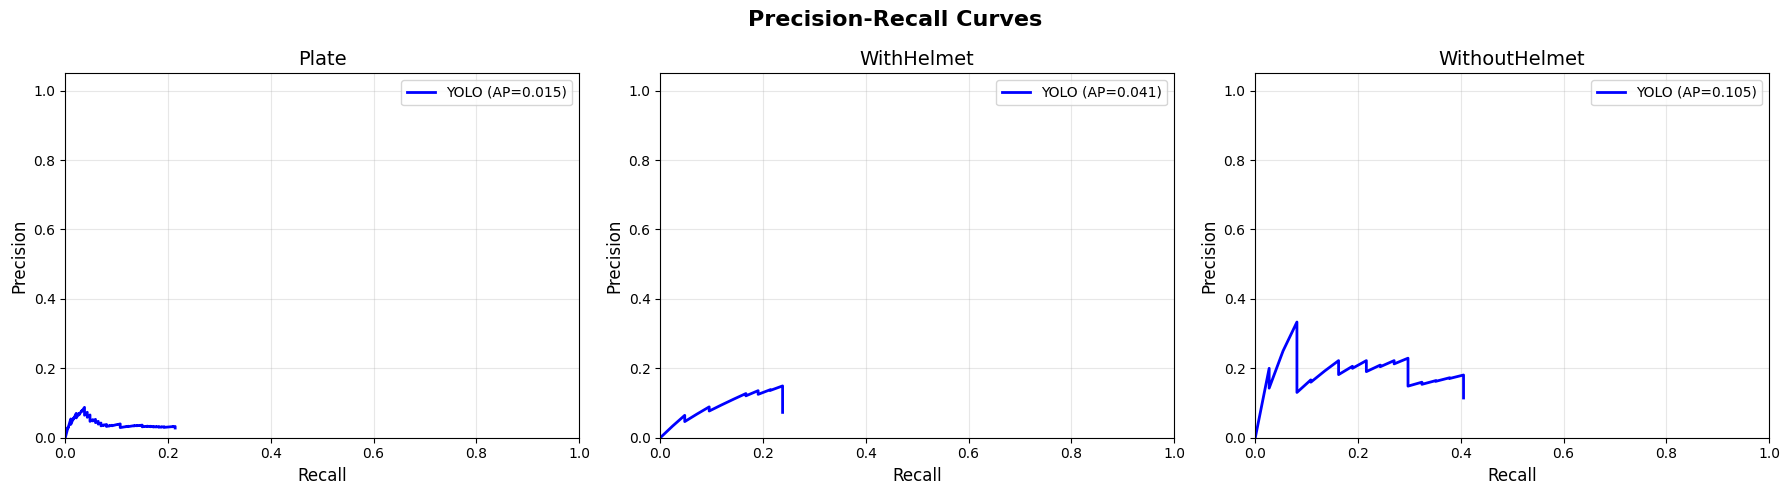

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_pr = ['#2196F3', '#4CAF50', '#FF5722']

for c in range(NUM_CLASSES):
    ax = axes[c]
    # YOLO
    if len(yolo_results[c]['recalls']) > 0:
        ax.plot(yolo_results[c]['recalls'], yolo_results[c]['precisions'],
                color='blue', linewidth=2, label=f"YOLO (AP={yolo_results[c]['ap']:.3f})")
    # FRCNN
    if len(frcnn_results[c]['recalls']) > 0:
        ax.plot(frcnn_results[c]['recalls'], frcnn_results[c]['precisions'],
                color='red', linewidth=2, label=f"FRCNN (AP={frcnn_results[c]['ap']:.3f})")

    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title(f'{CLASS_NAMES[c]}', fontsize=14)
    ax.legend(fontsize=10)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.3)

plt.suptitle('Precision-Recall Curves', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Plot IoU distribution histogram.


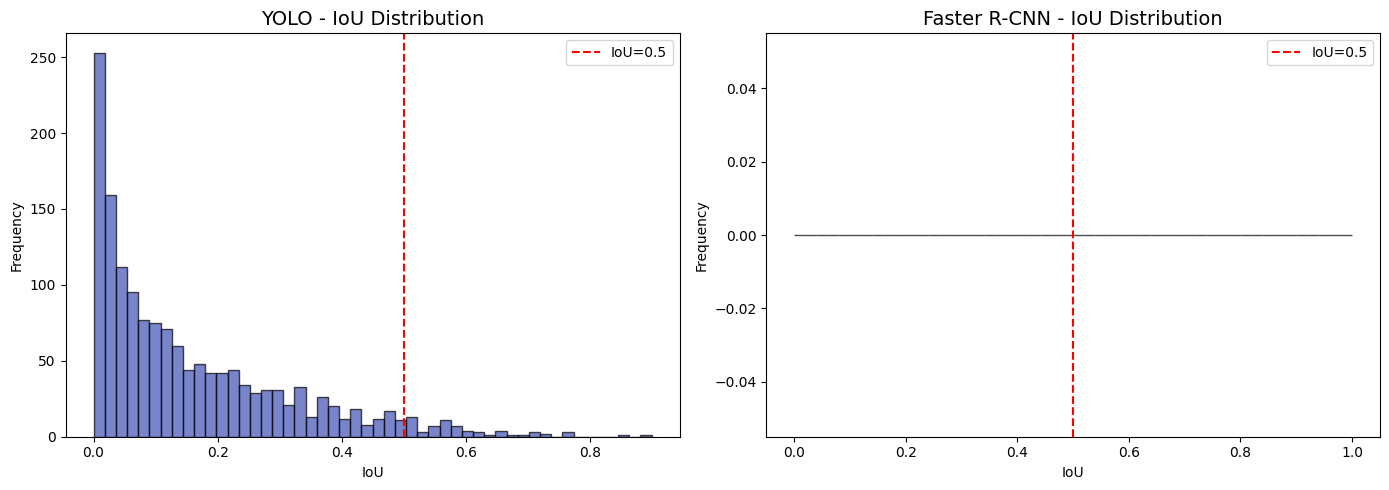

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(yolo_ious, bins=50, color='#3F51B5', alpha=0.7, edgecolor='black')
axes[0].set_title('YOLO - IoU Distribution', fontsize=14)
axes[0].set_xlabel('IoU')
axes[0].set_ylabel('Frequency')
axes[0].axvline(x=0.5, color='red', linestyle='--', label='IoU=0.5')
axes[0].legend()

axes[1].hist(frcnn_ious, bins=50, color='#E91E63', alpha=0.7, edgecolor='black')
axes[1].set_title('Faster R-CNN - IoU Distribution', fontsize=14)
axes[1].set_xlabel('IoU')
axes[1].set_ylabel('Frequency')
axes[1].axvline(x=0.5, color='red', linestyle='--', label='IoU=0.5')
axes[1].legend()

plt.tight_layout()
plt.show()

### Create comparison table for YOLO and R-CNN:

- mAP@0.5

- Precision

- Recall

- FPS

- Latency

- Model Size

In [ ]:
import pandas as pd

# Model sizes
def get_model_size_mb(model):
    total = sum(p.numel() * p.element_size() for p in model.parameters())
    return total / (1024 * 1024)

yolo_size = get_model_size_mb(model_yolo)
frcnn_size = get_model_size_mb(model_frcnn)

yolo_precision = np.mean([yolo_results[c]['precision'] for c in range(NUM_CLASSES)])
yolo_recall = np.mean([yolo_results[c]['recall'] for c in range(NUM_CLASSES)])
frcnn_precision = np.mean([frcnn_results[c]['precision'] for c in range(NUM_CLASSES)])
frcnn_recall = np.mean([frcnn_results[c]['recall'] for c in range(NUM_CLASSES)])

comparison = pd.DataFrame({
    'Metric': ['mAP@0.5', 'Precision', 'Recall', 'FPS', 'Latency (ms)', 'Model Size (MB)'],
    'YOLO (Custom)': [
        f"{yolo_mAP:.4f}",
        f"{yolo_precision:.4f}",
        f"{yolo_recall:.4f}",
        f"{yolo_fps:.1f}",
        f"{yolo_latency:.1f}",
        f"{yolo_size:.1f}"
    ],
    'Faster R-CNN (Custom)': [
        f"{frcnn_mAP:.4f}",
        f"{frcnn_precision:.4f}",
        f"{frcnn_recall:.4f}",
        f"{frcnn_fps:.1f}",
        f"{frcnn_latency:.1f}",
        f"{frcnn_size:.1f}"
    ]
})

print("\n" + "="*60)
print("       MODEL COMPARISON TABLE")
print("="*60)
print(comparison.to_string(index=False))
print("="*60)

# Also display as a styled table
from IPython.display import display, HTML
display(HTML(comparison.to_html(index=False, classes='table table-bordered')))


       MODEL COMPARISON TABLE
         Metric YOLO (Custom) Faster R-CNN (Custom)
        mAP@0.5        0.0533                0.0000
      Precision        0.0718                0.0000
         Recall        0.2858                0.0000
            FPS         869.1                   0.7
   Latency (ms)           1.2                1462.3
Model Size (MB)        1013.5                 145.0


Metric,YOLO (Custom),Faster R-CNN (Custom)
mAP@0.5,0.0533,0.0000
Precision,0.0718,0.0000
Recall,0.2858,0.0000
FPS,869.1,0.7
Latency (ms),1.2,1462.3
Model Size (MB),1013.5,145.0
